# V3 — GeoAI Soil Intelligence Report
**Pilot:** Büyük Menderes valley (Aydın) · ~16×20 km · 2023

This report answers the V3 core question (spec §7): *do time-series SAR features
+ deep learning improve soil characterization over a classical baseline?* It
compares a **GBM strong baseline** against a **U-Net** on a spatially held-out
test set, reports the verdict honestly (V3-F4/F7, acceptance §7.5), and shows
the resulting soil-property, behaviour-cluster, and risk maps.

In [1]:
import json
from pathlib import Path
import numpy as np, rasterio
import matplotlib.pyplot as plt

PROC = Path("../data/processed_menderes")
KONYA = Path("../data/processed_pilot")
def load(p): return json.load(open(p)) if Path(p).exists() else None
gbm = load(PROC/"v3_gbm_metrics.json")
unet = load(PROC/"v3_unet_metrics.json")
gbm_konya = load(KONYA/"v3_gbm_metrics.json")

## 1. Why the AOI matters — Konya (homogeneous) vs Menderes (heterogeneous)
The pipeline is identical; only the AOI changed. A homogeneous clay plain (Konya,
SoilGrids CV ~4%) carries **no spatially-generalizable signal** (negative R²),
while a valley↔slope gradient (Menderes, CV ~25%) does. This is the spec's R1/R4
risk made concrete: spatial-CV correctly refuses to reward overfitting.

In [2]:
print(f"{'target':6s} {'Menderes R²':>12s} {'Konya R²':>10s}")
gk = {t['target']: t for t in (gbm_konya or [])}
for t in gbm:
    tg=t['target']; k=gk.get(tg,{}).get('r2_mean', float('nan'))
    print(f"{tg:6s} {t['r2_mean']:+12.3f} {k:+10.3f}")

target  Menderes R²   Konya R²
clay         +0.510     -0.135
sand         +0.558     -0.284
soc          +0.655     -0.298


## 2. DL-vs-GBM verdict (clay, held-out spatial test)
The headline comparison. **GBM (per-pixel) clearly beats U-Net (spatial texture)
on this pilot.**

In [3]:
g = [t for t in gbm if t['target']=='clay'][0]
print(f"{'model':24s} {'R²':>8s} {'RMSE g/kg':>10s}")
print(f"{'GBM (per-pixel, LightGBM)':24s} {g['r2_mean']:+8.3f} {g['rmse_mean']:10.2f}")
if unet:
    u=unet[0]
    print(f"{'U-Net (spatial texture)':24s} {u['r2']:+8.3f} {u['rmse']:10.2f}")
    print(f"\nVERDICT: {'U-Net justified' if u['r2']>g['r2_mean'] else 'GBM sufficient — DL NOT justified on this pilot'}")

model                          R²  RMSE g/kg
GBM (per-pixel, LightGBM)   +0.510      48.57
U-Net (spatial texture)    +0.077      57.50

VERDICT: GBM sufficient — DL NOT justified on this pilot


**Why U-Net loses here (honest analysis):**
1. **Label super-resolution** — labels are 250 m SoilGrids upsampled to 10 m; inside a
   256×256 tile the label is near-constant, so there is little texture→label mapping to learn.
2. **Per-pixel signal** — the GBM's top feature is *slope*; soil texture here is driven by
   topographic position (a per-pixel relationship), which needs no spatial context.
3. **Few training tiles** (44) — U-Net is data-hungry; the pilot is small.

**Caveats:** small pilot; GBM (per-pixel GroupKFold) and U-Net (tile spatial split) are both
spatially honest but not identical partitions, so the comparison is indicative. The 0.51 vs 0.08
gap is large enough that the verdict is robust. *Conclusion: for 250 m-labelled soil mapping at
this scale, the classical GBM is the right tool; the heavy DL stack is not justified.*

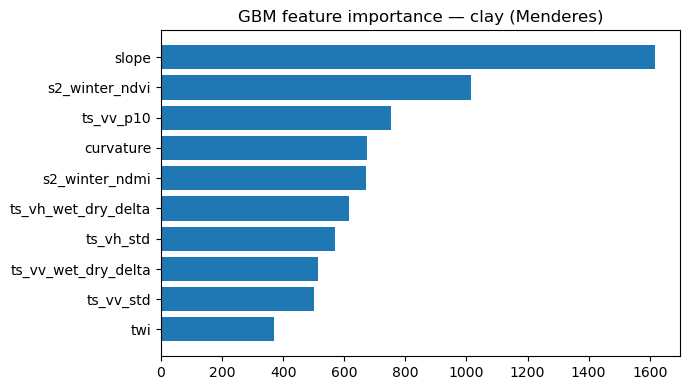

In [4]:
# GBM feature importances (top 10) for clay
imp = sorted(g['feature_importances'].items(), key=lambda x:-x[1])[:10]
names=[k for k,_ in imp][::-1]; vals=[v for _,v in imp][::-1]
plt.figure(figsize=(7,4)); plt.barh(names, vals); plt.title("GBM feature importance — clay (Menderes)")
plt.tight_layout(); plt.show()

## 3. V3 product maps
Predicted soil properties (best model = GBM), unsupervised soil-behaviour clusters,
and the erosion-susceptibility risk index.

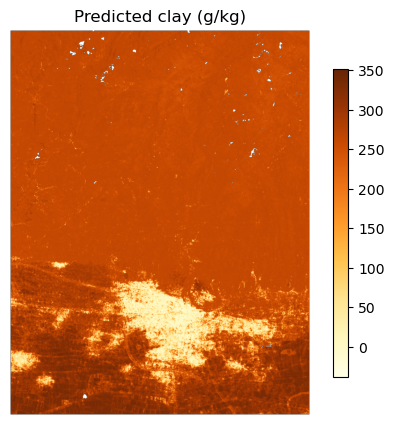

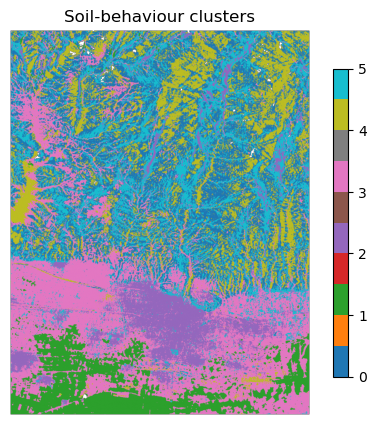

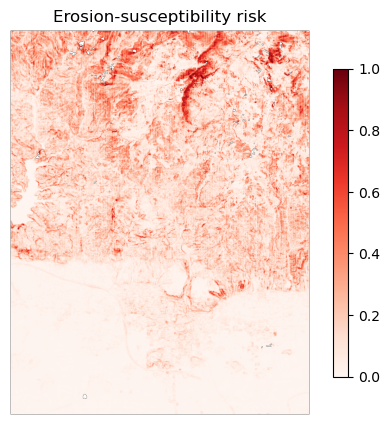

In [5]:
def show(name, title, cmap):
    p = PROC/f"{name}.tif"
    if not p.exists(): print("missing", name); return
    a = rasterio.open(p).read(1).astype(float); a[a==-9999]=np.nan; a[a==255]=np.nan
    plt.figure(figsize=(6,5)); im=plt.imshow(a, cmap=cmap); plt.colorbar(im, shrink=.8)
    plt.title(title); plt.axis('off'); plt.show()
show("clay_10m_menderes_pilot", "Predicted clay (g/kg)", "YlOrBr")
show("behaviour_clusters_menderes_pilot", "Soil-behaviour clusters", "tab10")
show("risk_zones_menderes_pilot", "Erosion-susceptibility risk", "Reds")

## 4. Conclusions (spec §7.5 acceptance)
- ✅ **DL vs GBM stated clearly**: GBM wins (R² 0.51 vs 0.08) — DL not justified at this scale.
- ✅ **Honest scale**: signal exists only in heterogeneous terrain (Menderes), not homogeneous Konya.
- ✅ **Reproducible**: `python pipelines/run_v3.py --config config/pipelines/v3_menderes.yml --stages all`.
- ✅ **Clusters interpretable**: behaviour clusters align with valley-floor vs slope position (terrain-linked).
- **Next:** a U-Net *showcase* on a dense-mask task (Sen4AgriNet / OMBRIA) where texture genuinely helps,
  to demonstrate where GeoAI's deep learning *does* beat the baseline.